In [1]:
# импорт нужных библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing # подключаем датасет из sklearn
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score

from sklearn import metrics
from collections import Counter

In [2]:
# сразу напишем код функции, которая будет вычислять все нужные метрики

def Reg_Models_Evaluation_Metrics (model,X_train,y_train,X_test,y_test,y_pred):
    cv_score = cross_val_score(estimator = model, X = X_train, y = y_train, cv = 10)

    # Calculating Adjusted R-squared
    r2 = model.score(X_test, y_test)
    # Number of observations is the shape along axis 0
    n = X_test.shape[0]
    # Number of features (predictors, p) is the shape along axis 1
    p = X_test.shape[1]
    # Adjusted R-squared formula
    adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
    RMSE = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    R2 = model.score(X_test, y_test)
    CV_R2 = cv_score.mean()

    print(f'RMSE:  {round(RMSE,4)}\n  R2: {round(R2,4)}\n Adjusted R2: {round(adjusted_r2, 4)}\n Cross Validated R2: {round(cv_score.mean(),4)}')
    return R2, adjusted_r2, CV_R2, RMSE

In [3]:
df_housing = fetch_california_housing()

In [4]:
# смотрим описание датасета

print(df_housing['DESCR'])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [5]:
# выведем названия фич
df_housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

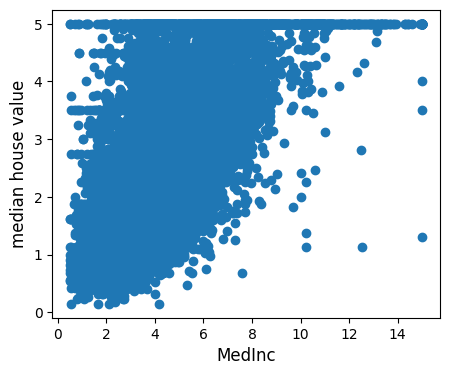

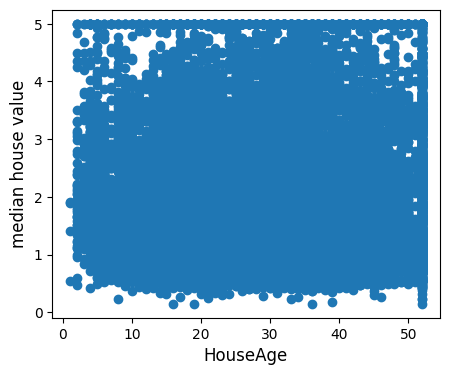

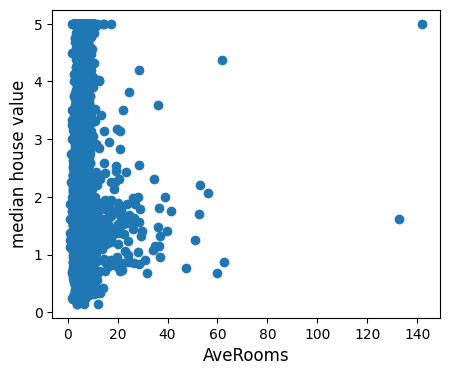

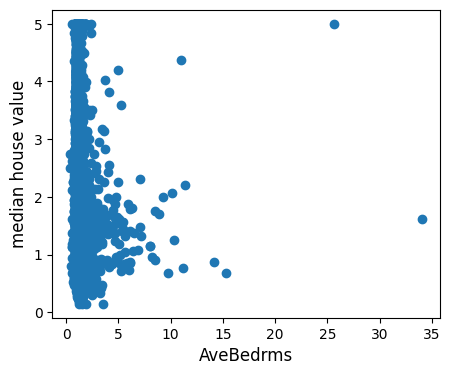

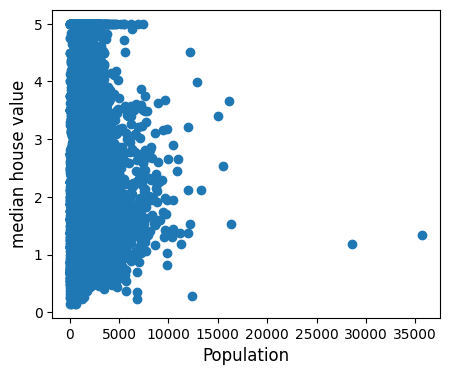

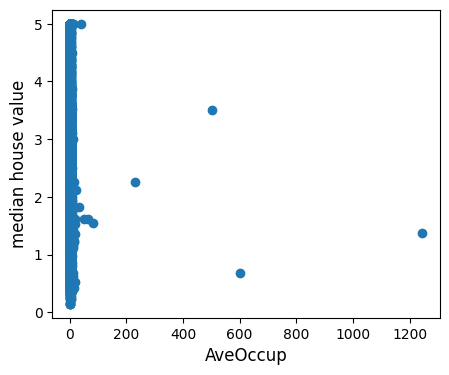

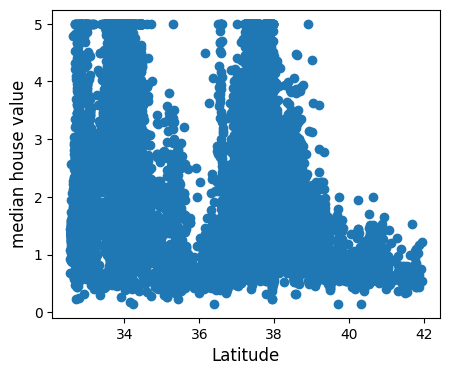

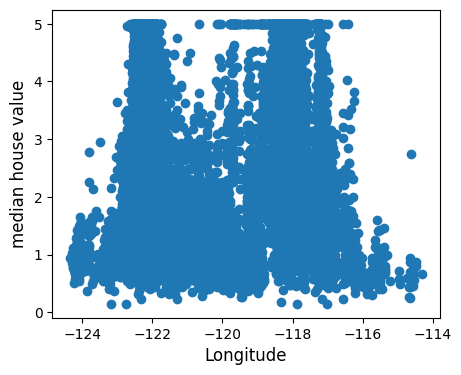

In [6]:
# нарисуем диаграммы рассеяния, чтобы лучше понять, как признаки (фичи) связаны с целевой переменной

for index, feature_name in enumerate(df_housing.feature_names):
    plt.figure(figsize=(5, 4))
    plt.scatter(df_housing.data[:, index], df_housing.target)
    plt.ylabel('median house value', size=12)
    plt.xlabel(feature_name, size=12)
    plt.show()

In [7]:
# загружаем данные в pandas dataframe
df = pd.DataFrame(data=df_housing.data,columns=df_housing.feature_names)
df["DP"] = df_housing.target
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,DP
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [8]:
# подготавливаем датасет к обучению

X = df.drop(['DP'], axis=1)
y = df['DP']
print(f'X shape: {X.shape} | y shape: {y.shape} ')

X shape: (20640, 8) | y shape: (20640,) 


In [9]:
# делим датасет на трейн и тест

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=15)

In [10]:
from sklearn.linear_model import LinearRegression

# Create a linear regression model
modelLR = LinearRegression()

# Fit the model to the data
modelLR.fit(X_train, y_train)

# Predict the response for a new data point
y_pr_LR = modelLR.predict(X_test)

In [11]:
_ = Reg_Models_Evaluation_Metrics(modelLR, X_train, y_train, X_test, y_test, y_pr_LR)


RMSE:  0.7342
  R2: 0.5946
 Adjusted R2: 0.5938
 Cross Validated R2: 0.6043


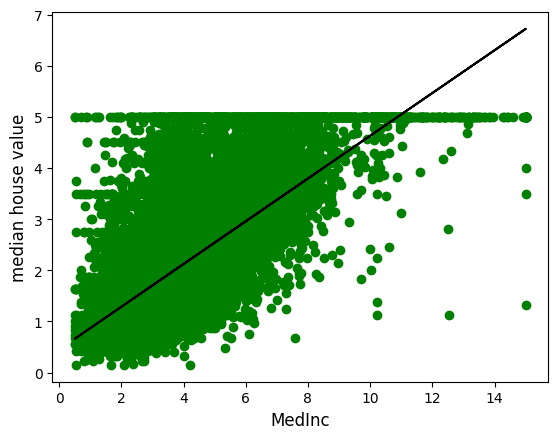

In [12]:
# попробуем отрисовать, как выглядит наша линейная регрессия

X2 = df['MedInc'].values[:,np.newaxis]
# target data is array of shape (n,)
y2 = df['DP'].values


model2 = LinearRegression()
model2.fit(X2, y2)

plt.scatter(X2, y2,color='g')
plt.plot(X2, model2.predict(X2),color='k')
plt.ylabel('median house value', size=12)
plt.xlabel('MedInc', size=12)
plt.show()

In [13]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(X)
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(poly_features, y, test_size=0.3, random_state=42)

In [14]:
# Create a linear regression model
modelPR = LinearRegression()

# Fit the model to the data
modelPR.fit(X_p_train, y_p_train)

# Predict the response for a new data point
y_pr_PR = modelPR.predict(X_p_test)

_ = Reg_Models_Evaluation_Metrics(modelPR, X_p_train, y_p_train, X_p_test, y_p_test, y_pr_PR)

RMSE:  0.6745
  R2: 0.6534
 Adjusted R2: 0.6509
 Cross Validated R2: -4.2838


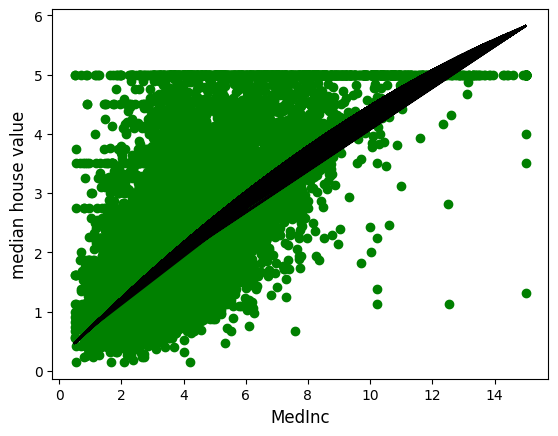

In [15]:
X2 = df['MedInc'].values[:,np.newaxis]
# target data is array of shape (n,)
y2 = df['DP'].values

poly_features = poly.fit_transform(X2)

model2 = LinearRegression()
model2.fit(poly_features, y2)


plt.scatter(X2, y2,color='g')
plt.plot(X2, model2.predict(poly.fit_transform(X2)),color='k')
plt.ylabel('median house value', size=12)
plt.xlabel('MedInc', size=12)
plt.show()

In [16]:
from sklearn.tree import DecisionTreeRegressor

# Create a stepwise regression model
modelDT = DecisionTreeRegressor()

# Fit the model to the data
modelDT.fit(X_train, y_train)

# Predict the response for a new data point
y_dt_pred = modelDT.predict(X_test)

In [17]:
_ = Reg_Models_Evaluation_Metrics(modelDT, X_train, y_train, X_test, y_test, y_dt_pred)

RMSE:  0.7046
  R2: 0.6267
 Adjusted R2: 0.6259
 Cross Validated R2: 0.6142


In [18]:
from sklearn.ensemble import RandomForestRegressor

# Create a stepwise regression model
modelRF = RandomForestRegressor(n_estimators=50)

# Fit the model to the data
modelRF.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelRF.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelRF, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  0.5244
  R2: 0.7932
 Adjusted R2: 0.7928
 Cross Validated R2: 0.8068


RMSE:  0.7377
  R2: 0.5908
 Adjusted R2: 0.59
 Cross Validated R2: -0.5786


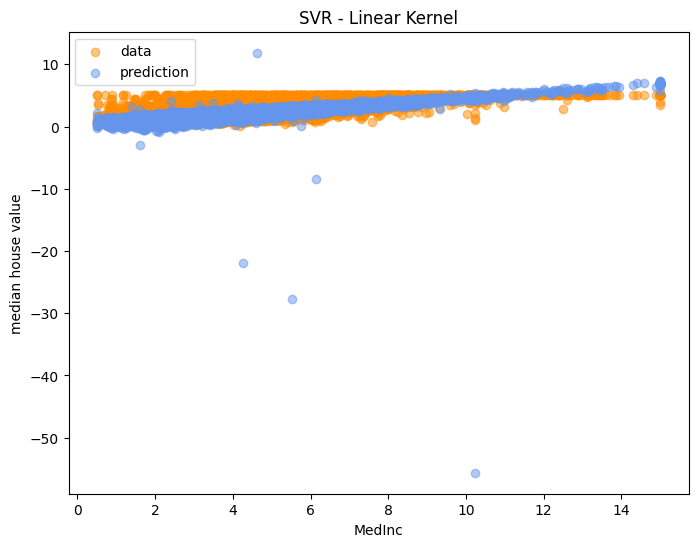

In [19]:
#SVR
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # ← numpy array
X_test_scaled = scaler.transform(X_test)

modelSVR = SVR(kernel='linear', cache_size=1000)
modelSVR.fit(X_train_scaled, y_train)
y_svr_pred = modelSVR.predict(X_test_scaled)
_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train_scaled, y_train, X_test_scaled, y_test, y_svr_pred)

# Визуализация — ИСПРАВЛЕНО!
plt.figure(figsize=(8, 6))
plt.scatter(X_train["MedInc"], y_train, color='darkorange', label='data', alpha=0.5)  # ← DataFrame по имени
plt.scatter(X_train["MedInc"], modelSVR.predict(X_train_scaled), color='cornflowerblue', label='prediction', alpha=0.5)
plt.xlabel('MedInc')
plt.ylabel('median house value')
plt.legend()
plt.title('SVR - Linear Kernel')
plt.show()

RMSE:  0.8558
  R2: 0.4492
 Adjusted R2: 0.4481
 Cross Validated R2: -597.9386


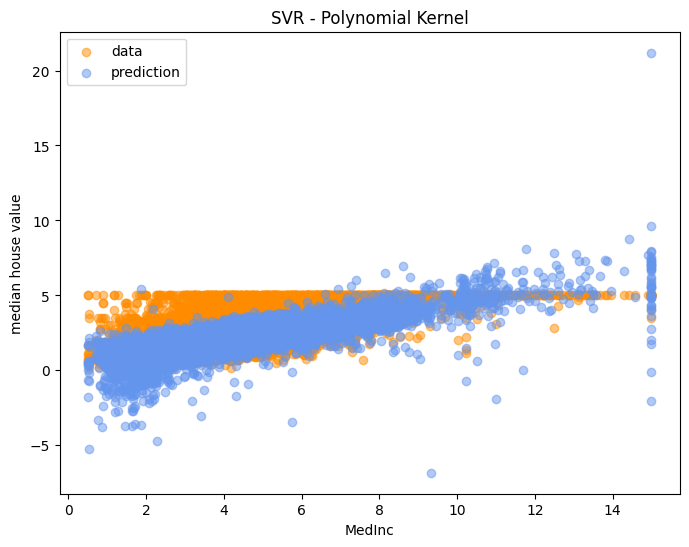

In [20]:
  #полиномиальная модель
modelSVR_poly = SVR(kernel='poly', cache_size=1000)
modelSVR_poly.fit(X_train_scaled, y_train)
y_svr_poly_pred = modelSVR_poly.predict(X_test_scaled)
_ = Reg_Models_Evaluation_Metrics(modelSVR_poly, X_train_scaled, y_train, X_test_scaled, y_test, y_svr_poly_pred)

# Визуализация — ИСПРАВЛЕНО!
plt.figure(figsize=(8, 6))
plt.scatter(X_train["MedInc"], y_train, color='darkorange', label='data', alpha=0.5)
plt.scatter(X_train["MedInc"], modelSVR_poly.predict(X_train_scaled), color='cornflowerblue', label='prediction', alpha=0.5)
plt.xlabel('MedInc')
plt.ylabel('median house value')
plt.legend()
plt.title('SVR - Polynomial Kernel')
plt.show()

RMSE:  0.6043
  R2: 0.7254
 Adjusted R2: 0.7248
 Cross Validated R2: 0.7373


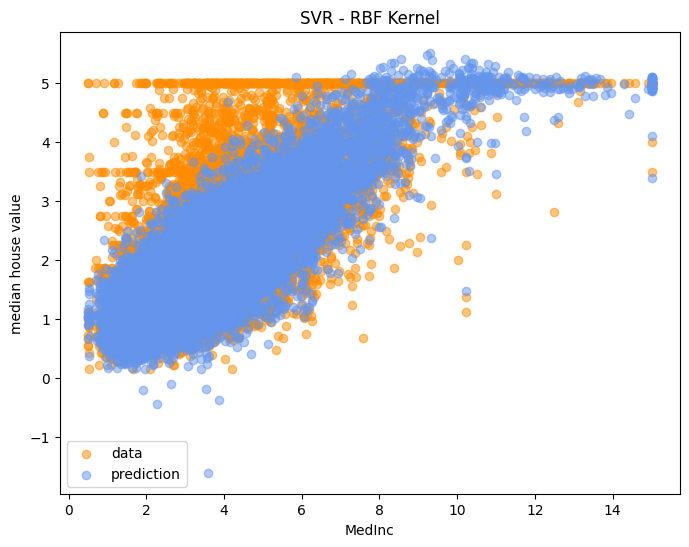

In [21]:
# Create a support vector regression model. Ядро - радиальная базисная функция
modelSVR_rbf = SVR(kernel='rbf', cache_size=1000)
modelSVR_rbf.fit(X_train_scaled, y_train)
y_svr_rbf_pred = modelSVR_rbf.predict(X_test_scaled)
_ = Reg_Models_Evaluation_Metrics(modelSVR_rbf, X_train_scaled, y_train, X_test_scaled, y_test, y_svr_rbf_pred)

# Визуализация — ИСПРАВЛЕНО!
plt.figure(figsize=(8, 6))
plt.scatter(X_train["MedInc"], y_train, color='darkorange', label='data', alpha=0.5)
plt.scatter(X_train["MedInc"], modelSVR_rbf.predict(X_train_scaled), color='cornflowerblue', label='prediction', alpha=0.5)
plt.xlabel('MedInc')
plt.ylabel('median house value')
plt.legend()
plt.title('SVR - RBF Kernel')
plt.show()

RMSE:  0.7818
  R2: 0.5403
 Adjusted R2: 0.5394
 Cross Validated R2: 0.563


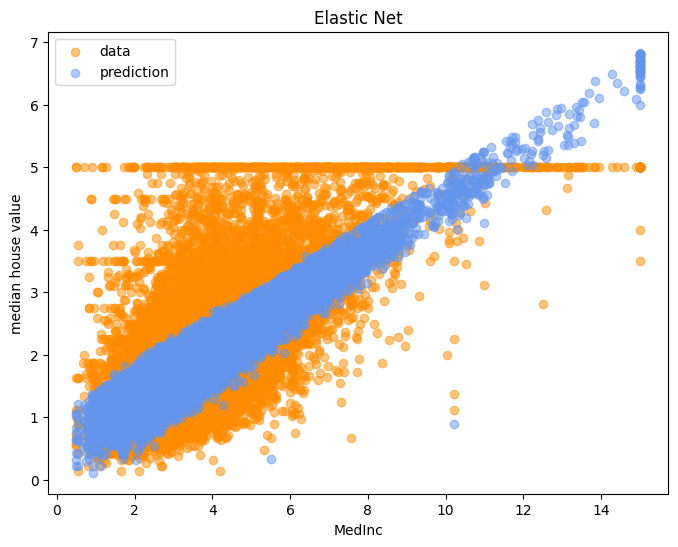

In [22]:
from sklearn.linear_model import ElasticNet

modelEN = ElasticNet(alpha=0.1, l1_ratio=0.8)
modelEN.fit(X_train, y_train)
y_en_pred = modelEN.predict(X_test)
_ = Reg_Models_Evaluation_Metrics(modelEN, X_train, y_train, X_test, y_test, y_en_pred)

# Визуализация — ИСПРАВЛЕНО!
plt.figure(figsize=(8, 6))
plt.scatter(X_train["MedInc"], y_train, color='darkorange', label='data', alpha=0.5)
plt.scatter(X_train["MedInc"], modelEN.predict(X_train), color='cornflowerblue', label='prediction', alpha=0.5)
plt.xlabel('MedInc')
plt.ylabel('median house value')
plt.legend()
plt.title('Elastic Net')
plt.show()